<a href="https://colab.research.google.com/github/dharmateja2019/ai-testcase-generator/blob/main/FineTuning_LearningCurves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install transformers,evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training:   0%|          | 0/1377 [00:00<?, ?it/s]


📊 Epoch 1 | Train Loss: 0.5089 | Val Loss: 0.4360 | Accuracy: 0.8260 | F1: 0.8849

📊 Epoch 2 | Train Loss: 0.3063 | Val Loss: 0.3489 | Accuracy: 0.8480 | F1: 0.8889

📊 Epoch 3 | Train Loss: 0.1441 | Val Loss: 0.4411 | Accuracy: 0.8456 | F1: 0.8930


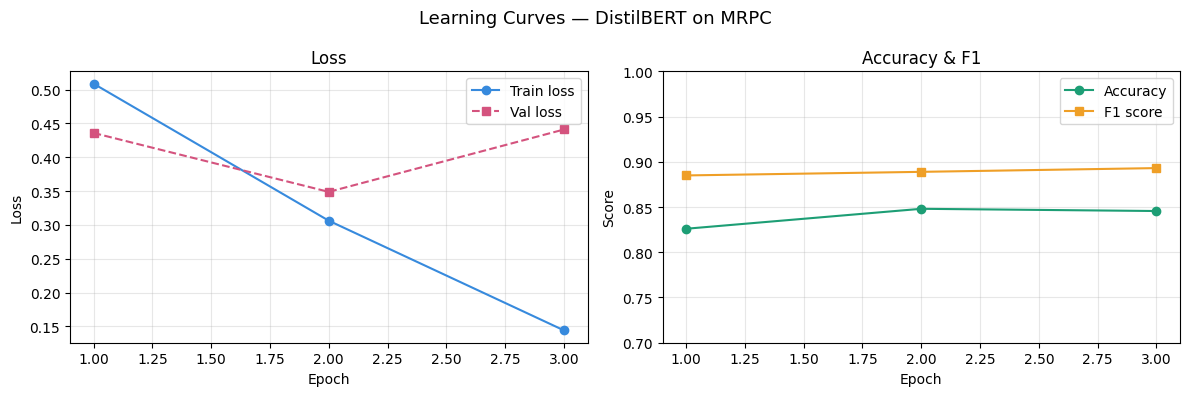

✅ Curves saved to learning_curves.png


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to ./mrpc-distilbert


In [14]:
# # ============================================================
# # FULL FINE-TUNING PIPELINE WITH ACCELERATE (CPU friendly)
# # ============================================================

# # ── 1. IMPORTS ──────────────────────────────────────────────
# from datasets import load_dataset
# from transformers import (
#     AutoTokenizer,
#     AutoModelForSequenceClassification,
#     DataCollatorWithPadding,
#     get_scheduler,
# )
# from torch.utils.data import DataLoader
# from torch.optim import AdamW
# from accelerate import Accelerator
# from tqdm.auto import tqdm
# import evaluate
# import numpy as np
# import torch

# # ── 2. LOAD & TOKENIZE DATASET ──────────────────────────────
# checkpoint = "distilbert-base-uncased"
# tokenizer = AutoTokenizer.from_pretrained(checkpoint)
# raw_datasets = load_dataset("glue", "mrpc")

# def tokenize_function(example):
#     return tokenizer(
#         example["sentence1"],
#         example["sentence2"],
#         truncation=True
#     )

# tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

# # Remove columns the model doesn't need
# tokenized_datasets = tokenized_datasets.remove_columns(
#     ["sentence1", "sentence2", "idx"]
# )
# # Rename label → labels (PyTorch expects "labels")
# tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
# tokenized_datasets.set_format("torch")  # return tensors directly

# print("✅ Dataset ready:", tokenized_datasets)

# # ── 3. DATALOADERS ──────────────────────────────────────────
# data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# train_dataloader = DataLoader(
#     tokenized_datasets["train"],
#     shuffle=True,
#     batch_size=8,          # ✅ small batch = CPU friendly
#     collate_fn=data_collator
# )
# eval_dataloader = DataLoader(
#     tokenized_datasets["validation"],
#     batch_size=8,
#     collate_fn=data_collator
# )

# print("✅ Dataloaders ready")
# print(f"   Train batches : {len(train_dataloader)}")
# print(f"   Eval  batches : {len(eval_dataloader)}")

# # ── 4. MODEL + OPTIMIZER ────────────────────────────────────
# model = AutoModelForSequenceClassification.from_pretrained(
#     checkpoint, num_labels=2
# )
# optimizer = AdamW(model.parameters(), lr=3e-5)

# # ── 5. ACCELERATOR SETUP ────────────────────────────────────
# accelerator = Accelerator()

# train_dl, eval_dl, model, optimizer = accelerator.prepare(
#     train_dataloader, eval_dataloader, model, optimizer
# )

# print(f"✅ Running on: {accelerator.device}")  # will show cpu

# # ── 6. SCHEDULER ────────────────────────────────────────────
# num_epochs = 3
# num_training_steps = num_epochs * len(train_dl)

# lr_scheduler = get_scheduler(
#     "linear",
#     optimizer=optimizer,
#     num_warmup_steps=0,
#     num_training_steps=num_training_steps,
# )

# print(f"✅ Total training steps: {num_training_steps}")

# # ── 7. TRAINING LOOP ────────────────────────────────────────
# metric = evaluate.load("glue", "mrpc")
# progress_bar = tqdm(range(num_training_steps), desc="Training")

# model.train()

# for epoch in range(num_epochs):
#     # ── Train ──
#     model.train()
#     for batch in train_dl:
#         outputs = model(**batch)
#         loss = outputs.loss
#         accelerator.backward(loss)   # ✅ instead of loss.backward()

#         optimizer.step()
#         lr_scheduler.step()
#         optimizer.zero_grad()
#         progress_bar.update(1)

#     # ── Evaluate after every epoch ──
#     model.eval()
#     for batch in eval_dl:
#         with torch.no_grad():
#             outputs = model(**batch)

#         logits = outputs.logits
#         predictions = np.argmax(
#             logits.cpu().numpy(), axis=-1   # ✅ .cpu() safe for both cpu/gpu
#         )
#         references = batch["labels"].cpu().numpy()
#         metric.add_batch(predictions=predictions, references=references)

#     results = metric.compute()
#     print(f"\n📊 Epoch {epoch + 1} — "
#           f"Accuracy: {results['accuracy']:.4f} | "
#           f"F1: {results['f1']:.4f}")

# print("\n✅ Training complete!")

# # ── 8. SAVE MODEL ───────────────────────────────────────────
# accelerator.wait_for_everyone()
# unwrapped_model = accelerator.unwrap_model(model)
# unwrapped_model.save_pretrained(
#     "mrpc-distilbert",
#     save_function=accelerator.save
# )
# tokenizer.save_pretrained("mrpc-distilbert")
# print("✅ Model saved to ./mrpc-distilbert")



# ============================================================
# FULL PIPELINE + LEARNING CURVES (no W&B needed)
# ============================================================

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, get_scheduler,
)
from torch.utils.data import DataLoader
from torch.optim import AdamW
from accelerate import Accelerator
from tqdm.auto import tqdm
import evaluate, numpy as np, torch
import matplotlib.pyplot as plt  # ✅ NEW

# ── LOAD & TOKENIZE ─────────────────────────────────────────
checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
raw_datasets = load_dataset("glue", "mrpc")

def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

# ── DATALOADERS ─────────────────────────────────────────────
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
train_dataloader = DataLoader(tokenized_datasets["train"], shuffle=True, batch_size=8, collate_fn=data_collator)
eval_dataloader  = DataLoader(tokenized_datasets["validation"], batch_size=8, collate_fn=data_collator)

# ── MODEL + OPTIMIZER ───────────────────────────────────────
model     = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)
optimizer = AdamW(model.parameters(), lr=3e-5)

# ── ACCELERATOR ─────────────────────────────────────────────
accelerator = Accelerator()
train_dl, eval_dl, model, optimizer = accelerator.prepare(
    train_dataloader, eval_dataloader, model, optimizer
)

# ── SCHEDULER ───────────────────────────────────────────────
num_epochs         = 3
num_training_steps = num_epochs * len(train_dl)
lr_scheduler = get_scheduler("linear", optimizer=optimizer,
                              num_warmup_steps=0,
                              num_training_steps=num_training_steps)

# ── TRACKING LISTS (NEW) ────────────────────────────────────
train_losses = []   # loss per step
epoch_train_losses = []
epoch_val_losses   = []
epoch_accuracies   = []
epoch_f1s          = []

# ── TRAINING LOOP ───────────────────────────────────────────
metric      = evaluate.load("glue", "mrpc")
progress_bar = tqdm(range(num_training_steps), desc="Training")

for epoch in range(num_epochs):
    # ── Train ──
    model.train()
    epoch_loss = 0
    for batch in train_dl:
        outputs = model(**batch)
        loss    = outputs.loss
        accelerator.backward(loss)
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

        # ✅ Record step-level loss
        train_losses.append(loss.item())
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_dl)
    epoch_train_losses.append(avg_train_loss)

    # ── Evaluate ──
    model.eval()
    total_val_loss = 0
    for batch in eval_dl:
        with torch.no_grad():
            outputs = model(**batch)
        total_val_loss += outputs.loss.item()
        preds = np.argmax(outputs.logits.cpu().numpy(), axis=-1)
        metric.add_batch(predictions=preds, references=batch["labels"].cpu().numpy())

    avg_val_loss = total_val_loss / len(eval_dl)
    epoch_val_losses.append(avg_val_loss)

    results = metric.compute()
    epoch_accuracies.append(results["accuracy"])
    epoch_f1s.append(results["f1"])

    print(f"\n📊 Epoch {epoch+1} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Accuracy: {results['accuracy']:.4f} | "
          f"F1: {results['f1']:.4f}")

# ── PLOT LEARNING CURVES (NEW) ──────────────────────────────
epochs_range = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Learning Curves — DistilBERT on MRPC", fontsize=13)

# Loss plot
axes[0].plot(epochs_range, epoch_train_losses, 'o-', label="Train loss", color="#378ADD")
axes[0].plot(epochs_range, epoch_val_losses,   's--',label="Val loss",   color="#D4537E")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy + F1 plot
axes[1].plot(epochs_range, epoch_accuracies, 'o-', label="Accuracy", color="#1D9E75")
axes[1].plot(epochs_range, epoch_f1s,        's-', label="F1 score", color="#EF9F27")
axes[1].set_title("Accuracy & F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0.7, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150)  # ✅ saves to file
plt.show()
print("✅ Curves saved to learning_curves.png")

# ── SAVE MODEL ──────────────────────────────────────────────
accelerator.wait_for_everyone()
unwrapped = accelerator.unwrap_model(model)
unwrapped.save_pretrained("mrpc-distilbert", save_function=accelerator.save)
tokenizer.save_pretrained("mrpc-distilbert")
print("✅ Model saved to ./mrpc-distilbert")